<a href="https://colab.research.google.com/github/s-m-i-l-y/Airport-Information-Dashboard/blob/main/Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io

%matplotlib inline

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

from google.colab import files

uploaded = files.upload()

# Assuming only one file is uploaded and it's a zip file
# Get the name of the uploaded file
uploaded_filename = list(uploaded.keys())[0]

# If the uploaded file is a zip, extract its contents
if uploaded_filename.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[uploaded_filename]), 'r') as z:
        z.extractall()
    # After extraction, the 'hotel_bookings.csv' should be in the current directory
    df = pd.read_csv("hotel_bookings.csv")
else:
    # If it's not a zip, assume it's the CSV directly
    df = pd.read_csv(uploaded_filename)

print("Dataset loaded successfully!")

Saving hotel_bookings[1].csv to hotel_bookings[1] (1).csv
Dataset loaded successfully!


In [30]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values before cleaning:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [31]:
# Fill missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

# Remove exact duplicate rows
df = df.drop_duplicates()

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("Dataset shape after cleaning:", df.shape)

df.info()

Missing values after cleaning:
0
Dataset shape after cleaning: (87396, 32)
<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                

In [32]:
# Total number of stay nights
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

# Total number of guests
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

# Estimated total booking value
df["booking_value"] = (
    df["adr"] * df["total_stay_nights"]
)

print(df[[
    "total_stay_nights",
    "total_guests",
    "booking_value"
]].head())


   total_stay_nights  total_guests  booking_value
0                  0           2.0            0.0
1                  0           2.0            0.0
2                  1           1.0           75.0
3                  1           1.0           75.0
4                  2           2.0          196.0


In [33]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = [
    "lead_time",
    "total_stay_nights",
    "total_guests",
    "adr",
    "total_of_special_requests"
]

scaler = MinMaxScaler()

df_normalized = df.copy()

df_normalized[columns_to_normalize] = scaler.fit_transform(
    df[columns_to_normalize]
)

df_normalized[columns_to_normalize].head()


,lead_time,total_stay_nights,total_guests,adr,total_of_special_requests
0,0.464043,0.000000,0.036364,0.001180,0.0
1,1.000000,0.000000,0.036364,0.001180,0.0
2,0.009498,0.014493,0.018182,0.015053,0.0
3,0.017639,0.014493,0.018182,0.015053,0.0
4,0.018996,0.028986,0.036364,0.019307,0.2


In [34]:
customer_summary = df.groupby(
    "customer_type"
).agg(
    total_bookings=("hotel", "count"),
    average_adr=("adr", "mean"),
    average_stay=("total_stay_nights", "mean"),
    total_booking_value=("booking_value", "sum"),
    average_special_requests=("total_of_special_requests", "mean")
).reset_index()

customer_summary


,customer_type,total_bookings,average_adr,average_stay,total_booking_value,average_special_requests
0,Contract,3139,92.753036,6.034406,1641846.82,0.838484
1,Group,544,84.361949,2.920956,135907.46,0.645221
2,Transient,71986,110.135859,3.578599,29247988.27,0.732073
3,Transient-Party,11727,87.675056,3.339729,3435196.76,0.457918


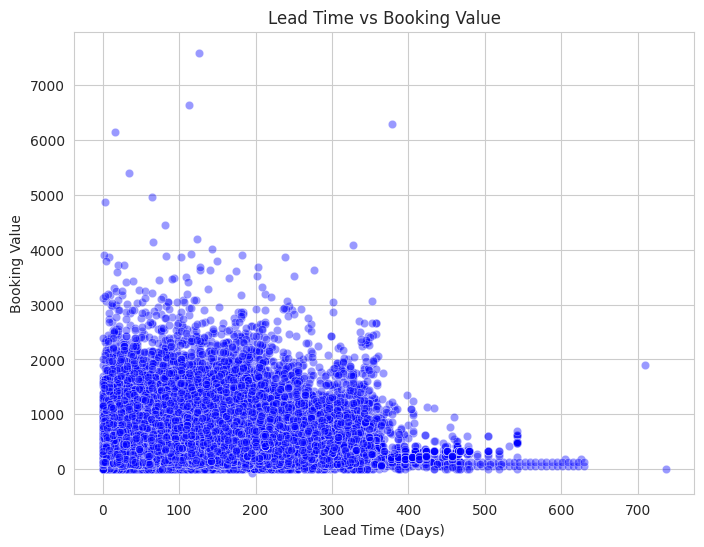

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="booking_value",
    alpha=0.4,
    color="blue"
)

plt.title("Lead Time vs Booking Value")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Booking Value")

plt.show()


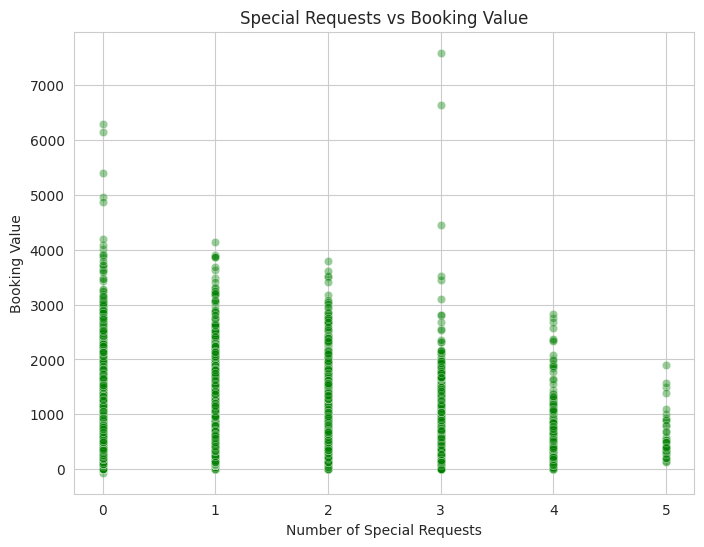

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_of_special_requests",
    y="booking_value",
    alpha=0.4,
    color="green"
)

plt.title("Special Requests vs Booking Value")
plt.xlabel("Number of Special Requests")
plt.ylabel("Booking Value")

plt.show()


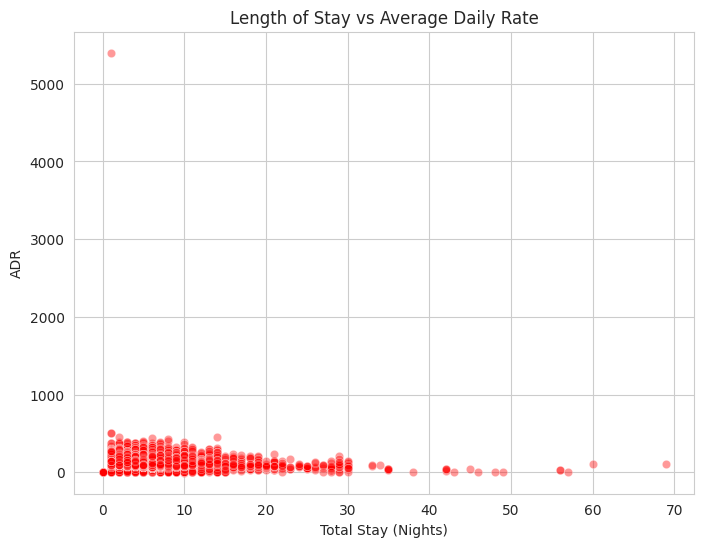

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_stay_nights",
    y="adr",
    alpha=0.4,
    color="red"
)

plt.title("Length of Stay vs Average Daily Rate")
plt.xlabel("Total Stay (Nights)")
plt.ylabel("ADR")

plt.show()
